<a href="https://colab.research.google.com/github/Alice16021/Bootcamp_python/blob/main/Projeto_final_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,Time,V1,V2,V3,V4,V5,Amount,Class
0,6960,0.062051,-0.583695,-0.844090,0.871284,0.075663,20.573953,0
1,61588,0.834263,-0.753754,-0.780880,2.694088,0.066640,44.167192,0
2,22420,-1.115122,1.856328,-1.789701,0.160981,-0.665218,74.989139,0
3,20618,0.308853,1.283719,0.256163,-2.207231,-0.362077,4.503465,0
4,25470,-0.574590,-0.213262,1.260069,-0.784257,-0.276515,2.594837,0



Proporção de Fraudes na base:
Class
0    98.0
1     2.0
Name: proportion, dtype: float64


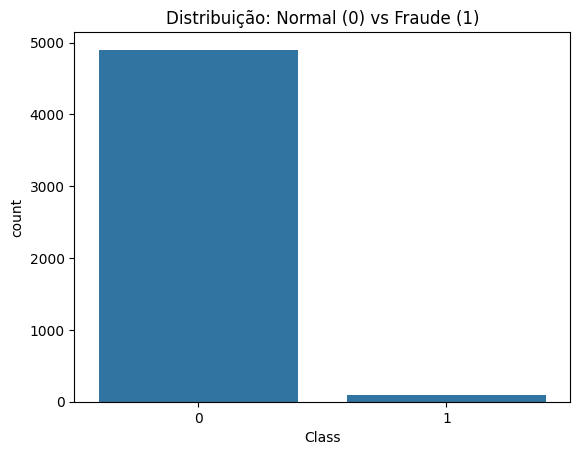

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/creditcard_amostra.csv')


display(df.head())

print("\nProporção de Fraudes na base:")
print(df['Class'].value_counts(normalize=True) * 100)

sns.countplot(x='Class', data=df)
plt.title('Distribuição: Normal (0) vs Fraude (1)')
plt.show()



In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Scaled_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Formato do Treino: {X_train.shape}")
print(f"Formato do Teste: {X_test.shape}")

Formato do Treino: (3500, 7)
Formato do Teste: (1500, 7)


In [15]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# XGBoost
scale_pos = y_train.value_counts()[0] / y_train.value_counts()[1]
xgb_model = XGBClassifier(scale_pos_weight=scale_pos, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


=== RELATÓRIO - REGRESSÃO LOGÍSTICA ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1470
           1       0.22      0.93      0.36        30

    accuracy                           0.93      1500
   macro avg       0.61      0.93      0.66      1500
weighted avg       0.98      0.93      0.95      1500


=== RELATÓRIO - XGBOOST ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1470
           1       0.77      0.67      0.71        30

    accuracy                           0.99      1500
   macro avg       0.88      0.83      0.85      1500
weighted avg       0.99      0.99      0.99      1500



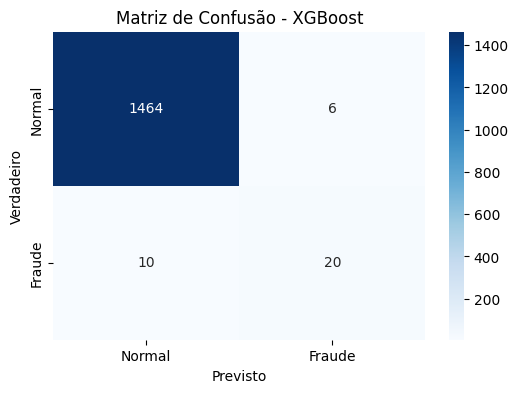

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

print("Regressão logística")
print(classification_report(y_test, lr_pred))

print("\n Relatório XGBOOST")
print(classification_report(y_test, xgb_pred))

# matriz de Confusão
plt.figure(figsize=(6, 4))
conf_matrix = confusion_matrix(y_test, xgb_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'])
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.title('Matriz de Confusão - XGBoost')
plt.show()

In [17]:

!pip install shap -q

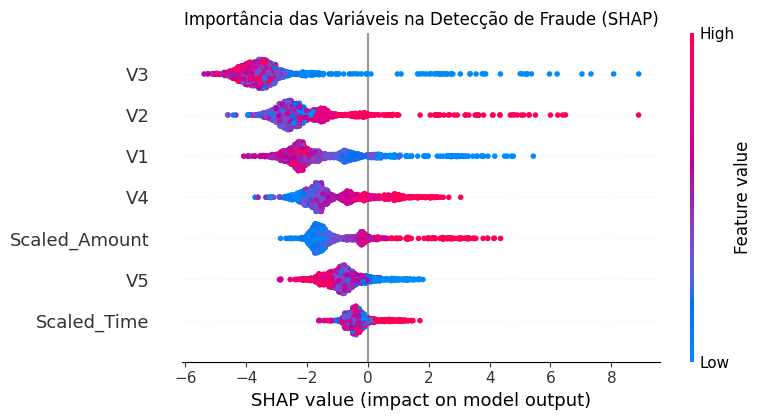

In [18]:
# gráfico SHAP
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.title('Importância das Variáveis na Detecção de Fraude (SHAP)')
shap.summary_plot(shap_values, X_test)